Configuring GPU settings...
✓ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

                          MOBILENET-UNET WITH FOCAL + EIOU + BOUNDARY LOSS                          
Loading train data...
  train: 400 samples
Loading val data...
  val: 400 samples
Loading test data...
  test: 400 samples
Split - Train: 600, Val: 200, Test: 400

TRAINING: Focal_EIoU_Boundary_MC
  Loss: Focal + EIoU + Boundary (α=0.7, β=0.3)
  Architecture: Deeper Decoder + MC Dropout

Model Configuration:
  Total Parameters: 37,131,395
  Dropout Layers: 5
  Dropout Rates: ['0.30', '0.30', '0.30', '0.21', '0.15']
  Loss: Focal + EIoU + Boundary
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8668 - dice_class_0: 0.9155 - dice_class_1: 0.4384 - dice_class_2: 0.3350 - dice_coef_multiclass: 0.5795 - iou_class_0: 0.8676 - iou_class_1: 0.3065 - iou_class_2: 0.2273 - iou_coef_multiclass: 0.4163 - loss: 0.9441
Epoch 1: val_loss improved from inf to 0.63713, saving 

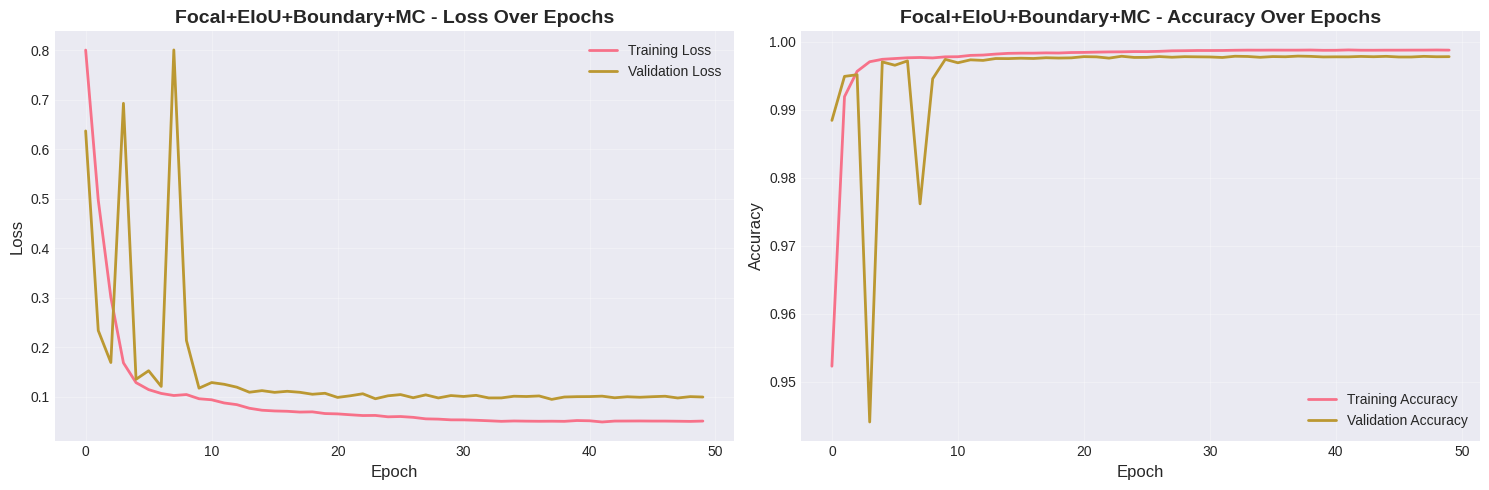

  ✓ Saved: results/Focal+EIoU+Boundary+MC_history.png


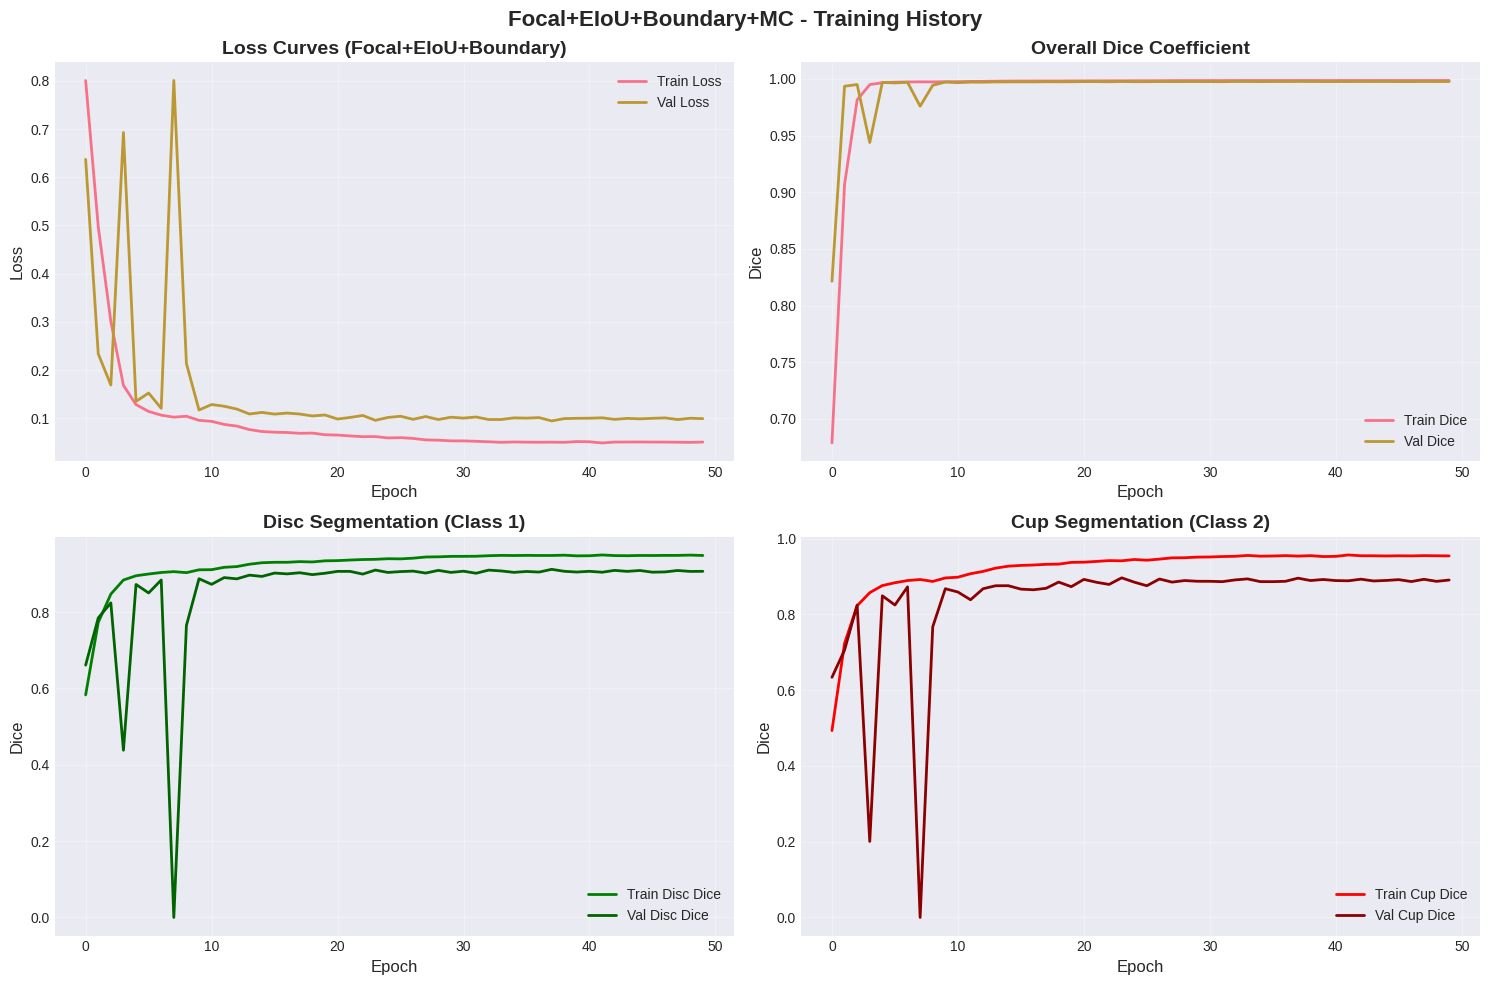

  ✓ Saved: results/Focal+EIoU+Boundary+MC_confusion_matrices.png


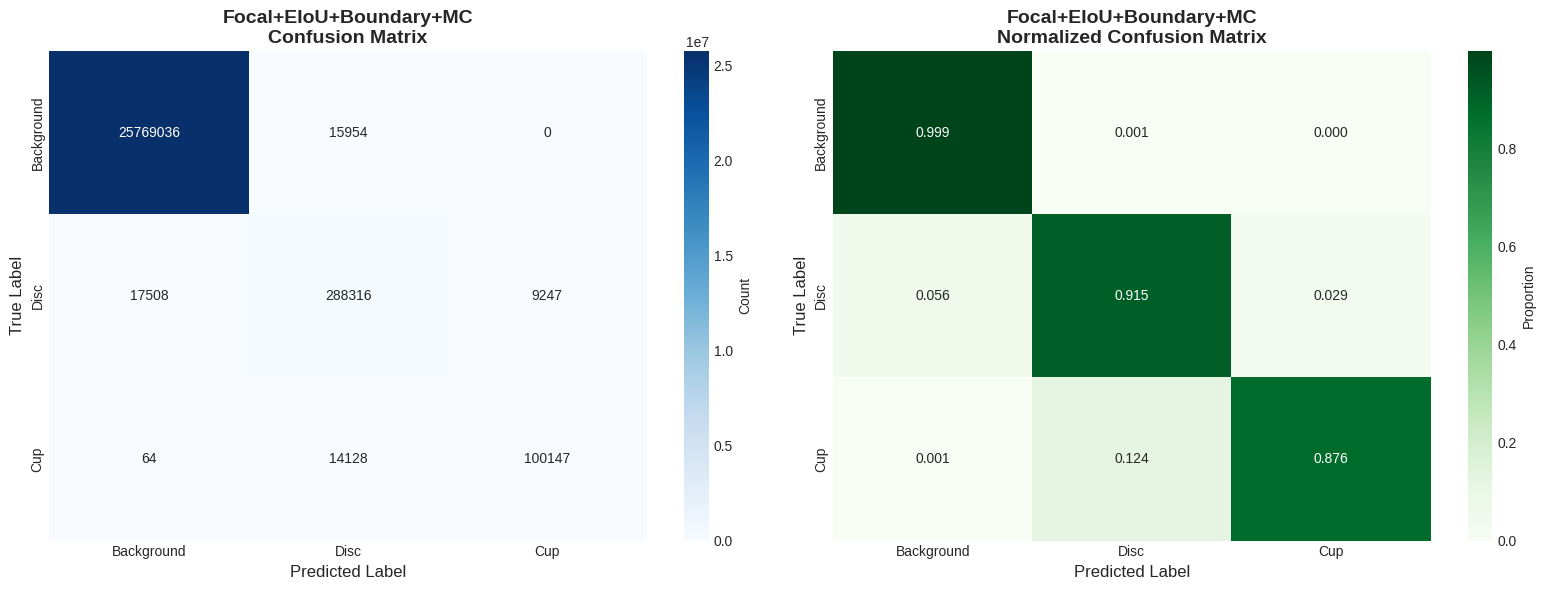


Confusion Matrix:
[[25769036    15954        0]
 [   17508   288316     9247]
 [      64    14128   100147]]

Normalized Confusion Matrix:
[[0.999 0.001 0.   ]
 [0.056 0.915 0.029]
 [0.001 0.124 0.876]]
  ✓ Saved: results/Focal+EIoU+Boundary+MC_predictions.png


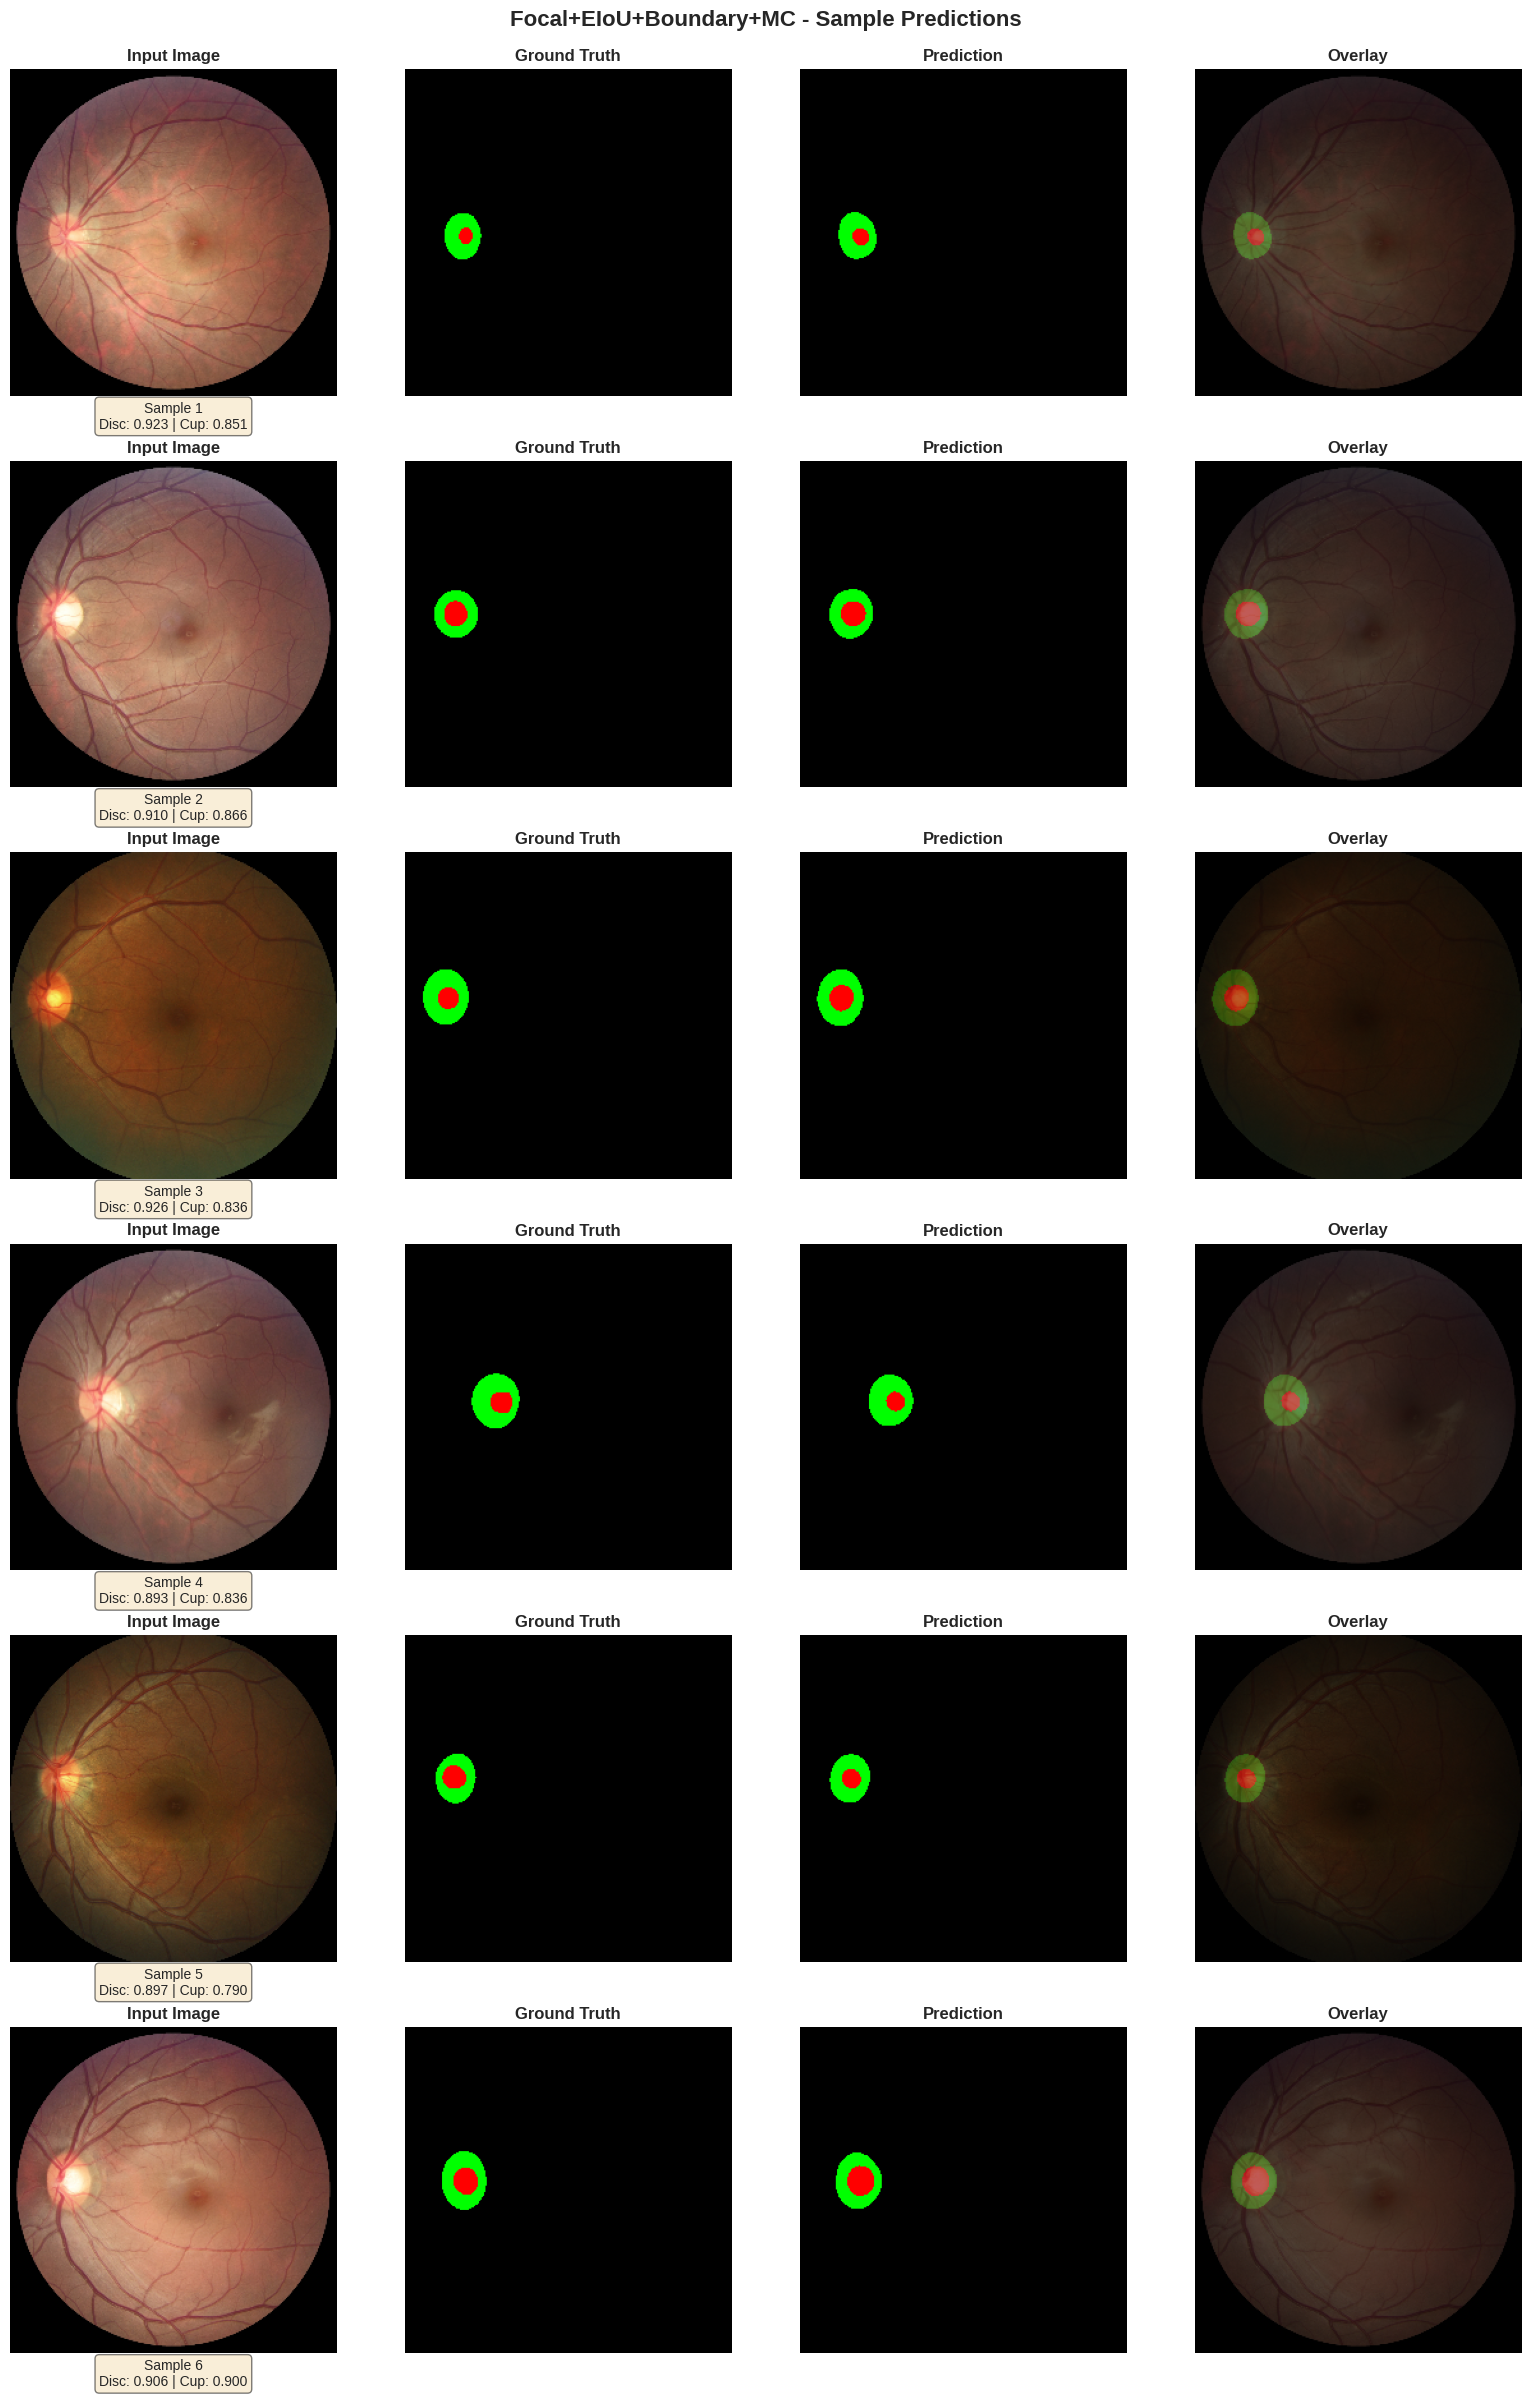


                                ✓ TRAINING AND EVALUATION COMPLETED!                                

Model: Deeper + Focal + EIoU + Boundary + MC Dropout
Loss Weights: α=0.7 (Focal+EIoU), β=0.3 (Boundary) [Literature-recommended]
Parameters: 37,131,395
Results saved in: results/




In [4]:
"""
ADVANCED MOBILENET-UNET WITH FOCAL + EIOU + BOUNDARY LOSS
==========================================================
Triple Loss Combination:
1. Focal Loss - Addresses class imbalance
2. Enhanced IoU Loss - Geometric accuracy with center/aspect penalties
3. Boundary Loss - Distance transform for sharp boundary delineation

Enhanced with:
- Deeper decoder architecture
- MC Dropout for uncertainty estimation
- Comprehensive visualization suite
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.ndimage import distance_transform_edt
import albumentations as A
import warnings
import gc
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# GPU CONFIGURATION
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for gpu in physical_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(physical_devices[0], 'GPU')
            print(f"✓ GPU found: {physical_devices}")
            return True
        except RuntimeError as e:
            print(f"✗ GPU configuration error: {e}")
            return False
    else:
        print("✗ No GPU found, using CPU")
        return False

# ============================================================================
# DATA LOADING
# ============================================================================

def load_images_masks(images_folder, masks_folder, img_size=(256,256)):
    """Load images and masks from folders"""
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        if base in mask_dict:
            img = cv2.imread(os.path.join(images_folder, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size) / 255.0
            
            mask = cv2.imread(os.path.join(masks_folder, mask_dict[base]), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            unique_vals = np.unique(mask)
            if len(unique_vals) > 3 or np.max(unique_vals) > 2:
                mask = np.clip(mask // 85, 0, 2).astype(np.uint8)
            
            images.append(img)
            masks.append(mask)
    
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    """Load all data from existing splits and merge"""
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks")
        )
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    
    all_images = np.concatenate(all_images, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    return all_images, all_masks

def create_new_split(all_images, all_masks):
    """Create new split: 600 train, 200 val, 400 test"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_masks, test_size=400, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=200, random_state=42
    )
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

def setup_augmentations():
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ])

def compute_distance_transform(mask):
    """
    Compute distance transform for boundary loss
    Returns normalized distance map where boundaries have high values
    """
    # Get boundaries by finding edges
    boundary = np.zeros_like(mask, dtype=np.float32)
    
    for class_id in range(3):
        class_mask = (mask == class_id).astype(np.uint8)
        
        # Find edges using morphological operations
        kernel = np.ones((3, 3), np.uint8)
        eroded = cv2.erode(class_mask, kernel, iterations=1)
        edge = class_mask - eroded
        
        # Compute distance transform from boundaries
        if np.any(edge):
            # Distance from boundary
            dist = distance_transform_edt(1 - edge)
            # Normalize and invert (higher weight near boundaries)
            dist_normalized = 1.0 / (1.0 + dist)
            boundary += dist_normalized * class_mask
    
    return boundary

def data_generator(images, masks, batch_size, augment=None):
    """Data generator - same as original"""
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    """Focal loss for addressing class imbalance"""
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]  # Lower weight for background
    
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        pt = y_pred_c
        focal_weight = K.pow(1.0 - pt, gamma)
        cross_entropy = -K.log(pt)
        focal_loss_c = alpha[c] * focal_weight * cross_entropy * y_true_c
        focal_loss_value += K.mean(focal_loss_c)
    
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    """Enhanced IoU loss with center distance and aspect ratio penalties"""
    eiou_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        # IoU calculation
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        # Image dimensions
        height = K.cast(K.shape(y_true_c)[1], 'float32')
        width = K.cast(K.shape(y_true_c)[2], 'float32')
        
        # Coordinate grids
        y_coords = K.arange(0, height)
        x_coords = K.arange(0, width)
        y_grid = K.tile(K.reshape(y_coords, (-1, 1)), (1, K.cast(width, 'int32')))
        x_grid = K.tile(K.reshape(x_coords, (1, -1)), (K.cast(height, 'int32'), 1))
        y_grid = K.cast(y_grid, 'float32')
        x_grid = K.cast(x_grid, 'float32')
        
        # Center distance penalty
        true_mass = K.sum(y_true_c, axis=[1, 2]) + smooth
        true_center_y = K.sum(y_true_c * y_grid, axis=[1, 2]) / true_mass
        true_center_x = K.sum(y_true_c * x_grid, axis=[1, 2]) / true_mass
        
        pred_mass = K.sum(y_pred_c, axis=[1, 2]) + smooth
        pred_center_y = K.sum(y_pred_c * y_grid, axis=[1, 2]) / pred_mass
        pred_center_x = K.sum(y_pred_c * x_grid, axis=[1, 2]) / pred_mass
        
        center_distance = K.square(true_center_y - pred_center_y) + K.square(true_center_x - pred_center_x)
        diagonal = K.square(height) + K.square(width)
        center_penalty = center_distance / (diagonal + smooth)
        
        # Aspect ratio penalty
        true_width = K.sqrt(K.sum(K.sum(y_true_c, axis=1), axis=1) + smooth)
        true_height = K.sqrt(K.sum(K.sum(y_true_c, axis=2), axis=1) + smooth)
        pred_width = K.sqrt(K.sum(K.sum(y_pred_c, axis=1), axis=1) + smooth)
        pred_height = K.sqrt(K.sum(K.sum(y_pred_c, axis=2), axis=1) + smooth)
        
        width_diff = K.square(pred_width - true_width)
        height_diff = K.square(pred_height - true_height)
        aspect_penalty = width_diff / (K.square(width) + smooth) + height_diff / (K.square(height) + smooth)
        
        # Combine
        eiou_c = 1.0 - iou + center_penalty + aspect_penalty
        eiou_loss_value += K.mean(eiou_c)
    
    return eiou_loss_value / 3.0

def boundary_loss(y_true, y_pred, smooth=1e-7):
    """
    Boundary loss using distance transform computed on-the-fly
    Focuses on accurate segmentation near class boundaries
    """
    import tensorflow as tf
    
    boundary_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        # Compute boundaries using morphological operations (TF ops)
        # Approximate boundary detection: |y_true_c - eroded(y_true_c)|
        kernel_size = 3
        y_true_c_expanded = tf.expand_dims(y_true_c, axis=-1)
        
        # Simple boundary detection: gradient magnitude
        dy = tf.abs(y_true_c_expanded[:, 1:, :, :] - y_true_c_expanded[:, :-1, :, :])
        dx = tf.abs(y_true_c_expanded[:, :, 1:, :] - y_true_c_expanded[:, :, :-1, :])
        
        # Pad to match original size
        dy = tf.pad(dy, [[0,0], [0,1], [0,0], [0,0]])
        dx = tf.pad(dx, [[0,0], [0,0], [0,1], [0,0]])
        
        boundary_weight = tf.squeeze(dy + dx, axis=-1)
        boundary_weight = boundary_weight + 1.0  # Add 1 to give weight to all pixels
        
        # Weighted binary cross-entropy at boundaries
        y_pred_c = K.clip(y_pred_c, smooth, 1.0 - smooth)
        bce = -(y_true_c * K.log(y_pred_c) + (1 - y_true_c) * K.log(1 - y_pred_c))
        
        # Apply boundary weights
        weighted_bce = bce * boundary_weight
        boundary_loss_value += K.mean(weighted_bce)
    
    return boundary_loss_value / 3.0

def focal_eiou_boundary_combined_loss(y_true, y_pred, 
                                     focal_weight=0.7, eiou_weight=0.7, boundary_weight=0.3,
                                     gamma=2.0, alpha=None):
    """
    Combined triple loss: Focal + EIoU + Boundary
    
    Args:
        focal_weight: Weight for focal loss (default: 0.7)
        eiou_weight: Weight for enhanced IoU loss (default: 0.7)
        boundary_weight: Weight for boundary loss (default: 0.3)
    """
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    boundary = boundary_loss(y_true, y_pred)
    
    return focal_weight * fl + eiou_weight * eiou + boundary_weight * boundary

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================

def enhanced_decoder_block(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """Enhanced decoder block with residual connections and dropout"""
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), activation='relu', 
                                      padding='same', name=f'{block_name}_skip_align')(skip_connection)
        skip_connection = layers.BatchNormalization(name=f'{block_name}_skip_bn')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    return x

def build_model_with_boundary(input_shape=(256, 256, 3), num_classes=3, dropout_rate=0.3):
    """Build MobileNetV2-UNet with deeper decoder and MC Dropout - same as original"""
    inputs = layers.Input(input_shape, dtype='float32')
    
    # Encoder (MobileNetV2 backbone)
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    skip_1 = backbone.get_layer('block_1_expand_relu').output
    skip_2 = backbone.get_layer('block_3_expand_relu').output
    skip_3 = backbone.get_layer('block_6_expand_relu').output
    skip_4 = backbone.get_layer('block_13_expand_relu').output
    bridge = backbone.output
    
    # Deeper bridge
    bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
    bridge = layers.BatchNormalization()(bridge)
    bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    # Decoder with enhanced blocks
    x = enhanced_decoder_block(bridge, skip_4, 512, 'decoder_1', dropout_rate)
    x = enhanced_decoder_block(x, skip_3, 256, 'decoder_2', dropout_rate)
    x = enhanced_decoder_block(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
    x = enhanced_decoder_block(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    
    # Final upsampling
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Segmentation output
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    # Print configuration
    dropout_layers = [layer for layer in model.layers if isinstance(layer, layers.Dropout)]
    print(f"\nModel Configuration:")
    print(f"  Total Parameters: {model.count_params():,}")
    print(f"  Dropout Layers: {len(dropout_layers)}")
    print(f"  Dropout Rates: {[f'{layer.rate:.2f}' for layer in dropout_layers]}")
    print(f"  Loss: Focal + EIoU + Boundary")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction for uncertainty estimation"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    predictions = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            X_batch = X[start_idx:end_idx]
            
            # Call model with training=True for dropout
            pred_batch = model(X_batch, training=True)
            batch_preds.append(pred_batch.numpy())
        
        pred = np.concatenate(batch_preds, axis=0)
        predictions.append(pred)
        
        if (i + 1) % 5 == 0:
            gc.collect()
    
    all_preds = np.array(predictions)
    mean_pred = np.mean(all_preds, axis=0)
    std_pred = np.std(all_preds, axis=0)
    
    del all_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    
    return mean_pred, std_pred

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_sample_predictions(model, X_test, y_test, model_name, num_samples=6, save_dir='results'):
    """Visualize sample predictions"""
    os.makedirs(save_dir, exist_ok=True)
    
    # Get predictions
    y_pred = model.predict(X_test[:num_samples], verbose=0, batch_size=4)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    colors = {0: [0, 0, 0], 1: [0, 255, 0], 2: [255, 0, 0]}
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title('Input Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            gt_colored[y_test[i] == class_id] = color
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Prediction
        pred_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            pred_colored[y_pred_labels[i] == class_id] = color
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Prediction', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
        
        # Overlay
        overlay = X_test[i].copy()
        for class_id, color in colors.items():
            if class_id > 0:
                mask = (y_pred_labels[i] == class_id).astype(np.float32)
                mask_rgb = np.stack([mask * color[0]/255, mask * color[1]/255, mask * color[2]/255], axis=-1)
                overlay = overlay * 0.6 + mask_rgb * 0.4
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay', fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')
        
        # Calculate dice
        y_test_cat = to_categorical(y_test[i], num_classes=3)
        y_pred_cat = to_categorical(y_pred_labels[i], num_classes=3)
        
        disc_dice = 2 * np.sum(y_test_cat[:,:,1] * y_pred_cat[:,:,1]) / (np.sum(y_test_cat[:,:,1]) + np.sum(y_pred_cat[:,:,1]) + 1e-7)
        cup_dice = 2 * np.sum(y_test_cat[:,:,2] * y_pred_cat[:,:,2]) / (np.sum(y_test_cat[:,:,2]) + np.sum(y_pred_cat[:,:,2]) + 1e-7)
        
        axes[i, 0].text(0.5, -0.1, f'Sample {i+1}\nDisc: {disc_dice:.3f} | Cup: {cup_dice:.3f}', 
                       transform=axes[i, 0].transAxes, ha='center', fontsize=10, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'{model_name} - Sample Predictions', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_predictions.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_predictions.png")
    plt.show()
    plt.close()

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss curves
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Loss Curves (Focal+EIoU+Boundary)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Overall Dice
    axes[0, 1].plot(history.history['dice_coef_multiclass'], label='Train Dice', linewidth=2)
    axes[0, 1].plot(history.history['val_dice_coef_multiclass'], label='Val Dice', linewidth=2)
    axes[0, 1].set_title('Overall Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Dice', fontsize=12)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Disc Dice
    axes[1, 0].plot(history.history['dice_class_1'], label='Train Disc Dice', linewidth=2, color='green')
    axes[1, 0].plot(history.history['val_dice_class_1'], label='Val Disc Dice', linewidth=2, color='darkgreen')
    axes[1, 0].set_title('Disc Segmentation (Class 1)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Dice', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Cup Dice
    axes[1, 1].plot(history.history['dice_class_2'], label='Train Cup Dice', linewidth=2, color='red')
    axes[1, 1].plot(history.history['val_dice_class_2'], label='Val Cup Dice', linewidth=2, color='darkred')
    axes[1, 1].set_title('Cup Segmentation (Class 2)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Dice', fontsize=12)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} - Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_history.png")
    plt.show()
    plt.close()

def plot_training_curves(history, model_name, save_dir='results'):
    """Plot training loss and accuracy curves"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_training_curves.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_training_curves.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrices"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    # Regular confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nNormalized Confusion Matrix:\n{np.round(cm_normalized, 3)}")
    
    return cm, cm_normalized

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, model_name, 
               augment=None, save_dir='results'):
    """Train model with Focal+EIoU+Boundary loss (same as deeper+focal+mc.py with boundary loss added)"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Loss: Focal + EIoU + Boundary (α=0.7, β=0.3)")
    print(f"  Architecture: Deeper Decoder + MC Dropout")
    
    K.clear_session()
    
    # Build model
    model = build_model_with_boundary(dropout_rate=0.3)
    param_count = model.count_params()
    
    # Compile with triple loss
    model.compile(
        optimizer=optimizers.Adam(learning_rate=5e-4),
        loss=focal_eiou_boundary_combined_loss,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    # Callbacks
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, 
                                verbose=1, monitor='val_loss', mode='min')
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, 
                                  verbose=1, mode='min', min_lr=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=20, verbose=1, 
                              restore_best_weights=True, mode='min')
    
    # Training
    batch_size = 4
    steps_train = X_train.shape[0] // batch_size
    steps_val = X_val.shape[0] // batch_size
    
    history = model.fit(
        data_generator(X_train, y_train, batch_size, augment),
        validation_data=data_generator(X_val, y_val, batch_size, None),
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=50,
        callbacks=[checkpoint, reduce_lr, early_stop],
        verbose=1
    )
    
    print(f"✓ Training completed")
    
    return model, history, param_count

def evaluate_model(model, X_test, y_test, model_name, run_mc_dropout=True, history=None, save_dir='results'):
    """Evaluate model"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test])
    
    # Predict
    y_pred = model.predict(X_test, verbose=0, batch_size=8)
    
    # Classification metrics
    y_true_labels = np.argmax(y_test_cat, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class:")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    # Per-class Dice and IoU
    results = {'standard': {}}
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (np.argmax(y_pred, axis=-1) == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    # MC Dropout
    if run_mc_dropout:
        print("\nMC Dropout Evaluation:")
        mean_pred, std_pred = mc_dropout_predict(model, X_test[:100], num_samples=10, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    # Generate visualizations AFTER printing all metrics
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    if history is not None:
        plot_training_curves(history, model_name, save_dir)
        plot_training_history(history, model_name, save_dir)
    
    plot_confusion_matrices(y_test_cat, y_pred, model_name, save_dir=save_dir)
    plot_sample_predictions(model, X_test, y_test, model_name, num_samples=6, save_dir=save_dir)
    
    return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Setup
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'MOBILENET-UNET WITH FOCAL + EIOU + BOUNDARY LOSS':^100s}")
    print(f"{'='*100}")
    
    # Load data
    all_images, all_masks = load_all_data(root_dir)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_new_split(all_images, all_masks)
    
    # Train model
    model, history, params = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test,
        "Focal_EIoU_Boundary_MC",
        augment=train_aug, save_dir=save_dir
    )
    
    # Evaluate
    results = evaluate_model(model, X_test, y_test, "Focal+EIoU+Boundary+MC", 
                            run_mc_dropout=True, history=history, save_dir=save_dir)
    
    print(f"\n{'='*100}")
    print(f"{'✓ TRAINING AND EVALUATION COMPLETED!':^100s}")
    print(f"{'='*100}")
    print(f"\nModel: Deeper + Focal + EIoU + Boundary + MC Dropout")
    print(f"Loss Weights: α=0.7 (Focal+EIoU), β=0.3 (Boundary) [Literature-recommended]")
    print(f"Parameters: {params:,}")
    print(f"Results saved in: {save_dir}/")
    print(f"\n{'='*100}\n")